# KTP Associate Pre-Interview Data Analysis Exercise · Pharmaceutical Formulation Comparison
**Formulations:** Lot A014 (Formulation A) vs Lot B025 (Formulation B)

---


In [ ]:
!pip install -r requirements.txt

## 0. Environment Setup

In [11]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
# from scipy.optimize import curve_fit
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'A014': '#2563EB', 'B025': '#DC2626'}
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
print('Libraries loaded ✓')


Libraries loaded ✓


---
## 1. Dataset Overview & Data Quality

### 1.1 Data Loading and Standardisation

In [12]:
def load_lot(path, sheet, lot_id):
    """Load one lot sheet, skip the merged header row, tidy column names."""
    raw = pd.read_excel(path, sheet_name=sheet, engine='xlrd', header=0)

    # Row 0 is a second header row (sample 1 / sample 2 labels) — drop it
    raw = raw.iloc[1:].reset_index(drop=True)

    raw.columns = [
        'start_date', 'pull_date', 'set_down_day', 'exposure_days',
        'oven', 'temp_c', 'rh_pct', 'analyst',
        'assay_s1', 'assay_s2',
        'imp092_s1', 'imp092_s2',
        'imp123_s1', 'imp123_s2'
    ]

    # Cast numeric columns
    num_cols = ['set_down_day', 'exposure_days', 'temp_c', 'rh_pct',
                'assay_s1', 'assay_s2', 'imp092_s1', 'imp092_s2',
                'imp123_s1', 'imp123_s2']
    for c in num_cols:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

    # Derived: mean of duplicate measurements
    raw['assay_mean']   = raw[['assay_s1',  'assay_s2' ]].mean(axis=1)
    raw['imp092_mean']  = raw[['imp092_s1', 'imp092_s2']].mean(axis=1)
    raw['imp123_mean']  = raw[['imp123_s1', 'imp123_s2']].mean(axis=1)

    # % difference between duplicates (reproducibility check)
    raw['assay_cv']  = (raw[['assay_s1','assay_s2']].std(axis=1) /
                         raw['assay_mean'] * 100)
    raw['imp092_cv'] = (raw[['imp092_s1','imp092_s2']].std(axis=1) /
                         raw['imp092_mean'] * 100)
    raw['imp123_cv'] = (raw[['imp123_s1','imp123_s2']].std(axis=1) /
                         raw['imp123_mean'] * 100)

    raw['lot'] = lot_id
    return raw

The workbook contains two sheets, one for each formulation: Lot A014 and Lot B025. The original Excel file uses merged/multi-row headers, so the columns were standardised to make the dataset easier to analyse consistently. Duplicate measurements were averaged to create one response value for assay and each impurity

### 1.2 Data Loading and Integration

In [13]:
DATA_PATH = 'KTP_task_datasets.xls'  
lot_A = load_lot(DATA_PATH, 'Lot A014', 'A014')
lot_B = load_lot(DATA_PATH, 'Lot B025', 'B025')
df    = pd.concat([lot_A, lot_B], ignore_index=True)

The two formulation datasets were loaded separately and combined into a single analysis dataset. A formulation identifier (lot) was retained to allow comparisons between Lot A014 and Lot B025 throughout the analysis. The combined dataset contains 40 observations, with 20 observations per formulation

In [14]:
print(f"Total records: {len(df)} ({len(lot_A)} per formulation)")

Total records: 40 (20 per formulation)


In [15]:
df.head()

,start_date,pull_date,set_down_day,exposure_days,oven,temp_c,rh_pct,analyst,assay_s1,assay_s2,...,imp092_s2,imp123_s1,imp123_s2,assay_mean,imp092_mean,imp123_mean,assay_cv,imp092_cv,imp123_cv,lot
0,2025-12-18,2026-01-08,0.0,21.0,Oven 2,70.0,11.0,RG,8.185,8.119,...,0.282,0.074,0.074,8.1520,0.2850,0.074,0.572486,1.488646,0.000000,A014
1,2025-12-18,2026-01-08,0.0,21.0,Oven 4,65.0,25.0,SS,11.184,10.702,...,0.215,0.134,0.136,10.9430,0.2305,0.135,3.114552,9.509896,1.047566,A014
2,2025-12-18,2026-01-08,0.0,21.0,Oven 1,50.0,64.0,SS,12.100,12.238,...,0.222,0.191,0.189,12.1690,0.2220,0.190,0.801880,0.000000,0.744323,A014
3,2025-12-18,2026-01-08,0.0,21.0,Oven 3,60.0,80.0,CM,11.518,11.095,...,0.673,0.167,0.171,11.3065,0.6620,0.169,2.645436,2.349902,1.673626,A014
4,2025-12-18,2026-01-08,0.0,21.0,Oven 3,60.0,42.0,CM,11.813,11.294,...,0.541,0.176,0.176,11.5535,0.5340,0.176,3.176426,1.853838,0.000000,A014


### 1.3 Dataset Structure and Completeness

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   start_date     38 non-null     datetime64[ns]
 1   pull_date      38 non-null     datetime64[ns]
 2   set_down_day   40 non-null     float64       
 3   exposure_days  40 non-null     float64       
 4   oven           40 non-null     object        
 5   temp_c         38 non-null     float64       
 6   rh_pct         38 non-null     float64       
 7   analyst        40 non-null     object        
 8   assay_s1       40 non-null     float64       
 9   assay_s2       40 non-null     float64       
 10  imp092_s1      40 non-null     float64       
 11  imp092_s2      40 non-null     float64       
 12  imp123_s1      40 non-null     float64       
 13  imp123_s2      40 non-null     float64       
 14  assay_mean     40 non-null     float64       
 15  imp092_mean    40 non-nul

In [17]:
missing = df.isna().sum()
missing[missing > 0]

start_date    2
pull_date     2
temp_c        2
rh_pct        2
imp092_cv     2
dtype: int64

The combined dataset contains 40 observations and 21 variables. The primary analytical response variables (assay and impurity measurements) are complete, with no missing values. A small number of missing values were identified in the date, temperature and humidity fields, corresponding to the control samples that were not exposed to accelerated storage conditions. Missing values in the Impurity RRT 0.92 CV calculation arise because the control samples contain zero impurity, making the coefficient of variation undefined. These missing values are expected and are unlikely to affect the subsequent analysis.

### 1.4 Summary of Experimental Conditions

In [18]:
# Lot A014
lot_A[['set_down_day','exposure_days','temp_c','rh_pct',
             'assay_mean','imp092_mean','imp123_mean']].describe().round(3)

,set_down_day,exposure_days,temp_c,rh_pct,assay_mean,imp092_mean,imp123_mean
count,20.000,20.000,19.000,19.000,20.000,20.000,20.000
mean,8.900,12.100,62.632,48.211,11.492,0.321,0.278
std,8.372,8.372,6.946,24.280,1.242,0.173,0.185
min,0.000,0.000,50.000,11.000,8.152,0.000,0.074
25%,0.000,4.250,60.000,25.000,11.264,0.208,0.168
50%,7.000,14.000,65.000,42.000,11.959,0.283,0.196
75%,16.750,21.000,70.000,64.000,12.227,0.496,0.384
max,21.000,21.000,70.000,80.000,12.799,0.662,0.747


In [19]:
# Lot B025
lot_B[['set_down_day','exposure_days','temp_c','rh_pct',
             'assay_mean','imp092_mean','imp123_mean']].describe().round(3)

,set_down_day,exposure_days,temp_c,rh_pct,assay_mean,imp092_mean,imp123_mean
count,20.000,20.000,19.000,19.000,20.000,20.000,20.000
mean,8.900,12.100,62.632,48.211,11.398,0.339,0.377
std,8.372,8.372,6.946,24.280,1.201,0.182,0.208
min,0.000,0.000,50.000,11.000,8.216,0.000,0.113
25%,0.000,4.250,60.000,25.000,11.109,0.222,0.248
50%,7.000,14.000,65.000,42.000,11.845,0.296,0.310
75%,16.750,21.000,70.000,64.000,12.187,0.484,0.490
max,21.000,21.000,70.000,80.000,12.606,0.718,0.885


Both formulations were tested under the same experimental conditions, with identical ranges of exposure time, temperature and relative humidity. This balanced design enables direct comparison of formulation performance. Preliminary summary statistics suggest that Lot A014 exhibits slightly higher assay values and lower impurity levels than Lot B025, although formal analysis is required to determine whether these differences are meaningful.

### 1.5 Duplicate Measurement Reproducibility

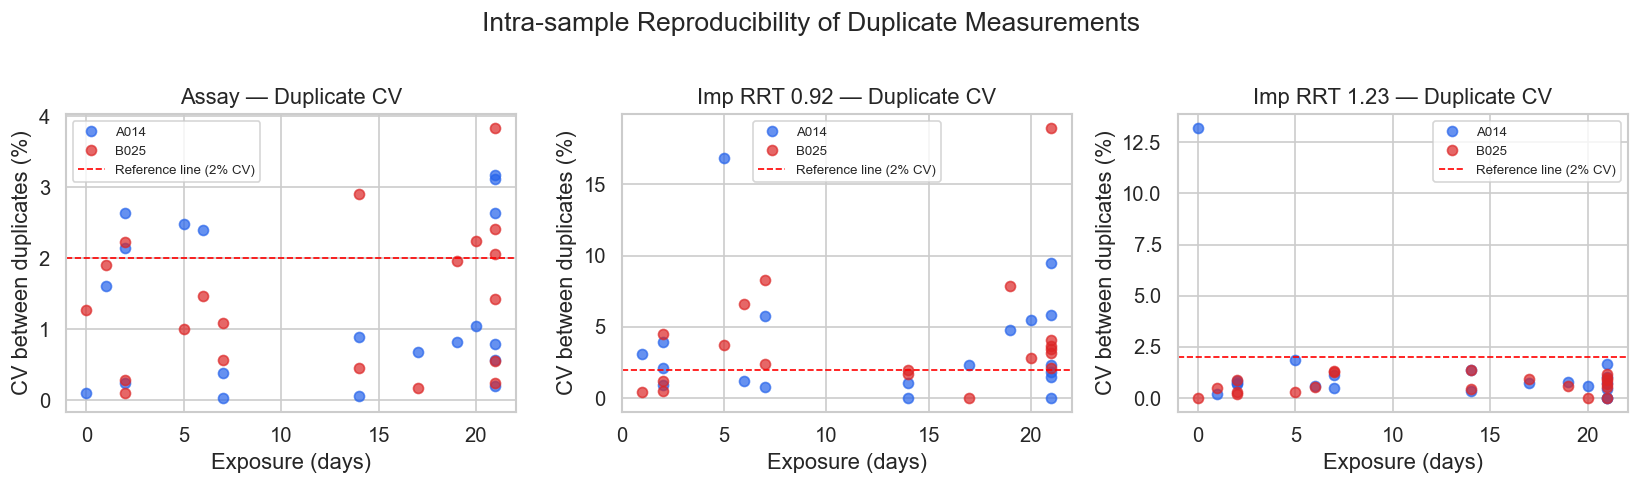

Max CVs:
  A014  assay=3.18%  imp092=16.85%  imp123=13.20%
  B025  assay=3.84%  imp092=18.97%  imp123=1.36%


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('assay_cv',  'Assay'),
           ('imp092_cv', 'Imp RRT 0.92'),
           ('imp123_cv', 'Imp RRT 1.23')]

for ax, (col, label) in zip(axes, metrics):
    for lot_id, grp in df.groupby('lot'):
        ax.plot(grp['exposure_days'], grp[col], 'o',
                color=PALETTE[lot_id], label=lot_id, alpha=0.7)
    ax.axhline(2, color='red', ls='--', lw=1, label='Reference line (2% CV)')
    ax.set_xlabel('Exposure (days)')
    ax.set_ylabel('CV between duplicates (%)')
    ax.set_title(f'{label} — Duplicate CV')
    ax.legend(fontsize=8)

plt.suptitle('Intra-sample Reproducibility of Duplicate Measurements', y=1.01)
plt.tight_layout()
plt.savefig('fig1_duplicate_cv.png')
plt.show()

print("Max CVs:")
for lot_id, grp in df.groupby('lot'):
    print(f"  {lot_id}  assay={grp['assay_cv'].max():.2f}%  "
          f"imp092={grp['imp092_cv'].max():.2f}%  "
          f"imp123={grp['imp123_cv'].max():.2f}%")


A 2% coefficient of variation (CV) reference line is included as a visual aid to compare duplicate measurement variability across observations. This line is not intended to represent a formal acceptance criterion, but rather provides a practical benchmark for assessing the consistency of duplicate measurements. Values above the reference line indicate relatively greater variability between duplicate measurements and should be interpreted in the context of the measured concentration, particularly for impurity levels where small absolute differences can result in large percentage changes.

### 1.6 Key Findings from Data Quality Assessment

**Key structural observations:**

| Feature | Detail |
|---|---|
| Sheets | Two lots (A014, B025), each with 20 test records |
| Design | Samples set down across 7 distinct days; all pulled on ~8 Jan 2026 |
| Conditions | 4 ovens · temperatures: 50, 60, 65, 70 °C · %RH: 11–80 |
| Replicates | Duplicate measurements (Sample 1 & 2) for every analytical endpoint |
| Analysts | 3 analysts (RG, SS, CM) — potential inter-analyst variability |
| Response variables | Assay (mg/tablet), Impurity RRT 0.92 (%), Impurity RRT 1.23 (%) |

**Experimental Design Observation:** samples were set down at different days but *all pulled on the same date*. This means shorter exposure = set down later. The variable `exposure_days` (= pull_date − start_date) correctly captures actual stress duration.


The dataset contains two prototype formulations (Lot A014 and Lot B025), each evaluated under matched accelerated stability conditions across a range of temperatures, humidity levels and exposure durations. Data preparation required standardisation of the original worksheet structure and consolidation of duplicate measurements into averaged analytical responses.

Overall data quality was good, with complete assay and impurity measurements available for all observations. The small number of missing values identified were associated with control samples and are not expected to materially affect the subsequent analysis. Duplicate measurements generally demonstrated good agreement, providing confidence in the analytical results and supporting the use of averaged values throughout the study.

The experimental design enables direct comparison of the two formulations because both lots were tested under equivalent environmental conditions. Preliminary descriptive statistics suggest that Lot A014 may exhibit slightly higher assay values and lower impurity levels than Lot B025; however, further analysis is required to determine whether these differences are meaningful and to identify the factors most strongly associated with product degradation.

---
## 2. Insights from the Data

### 2.1 Assay vs Exposure Time

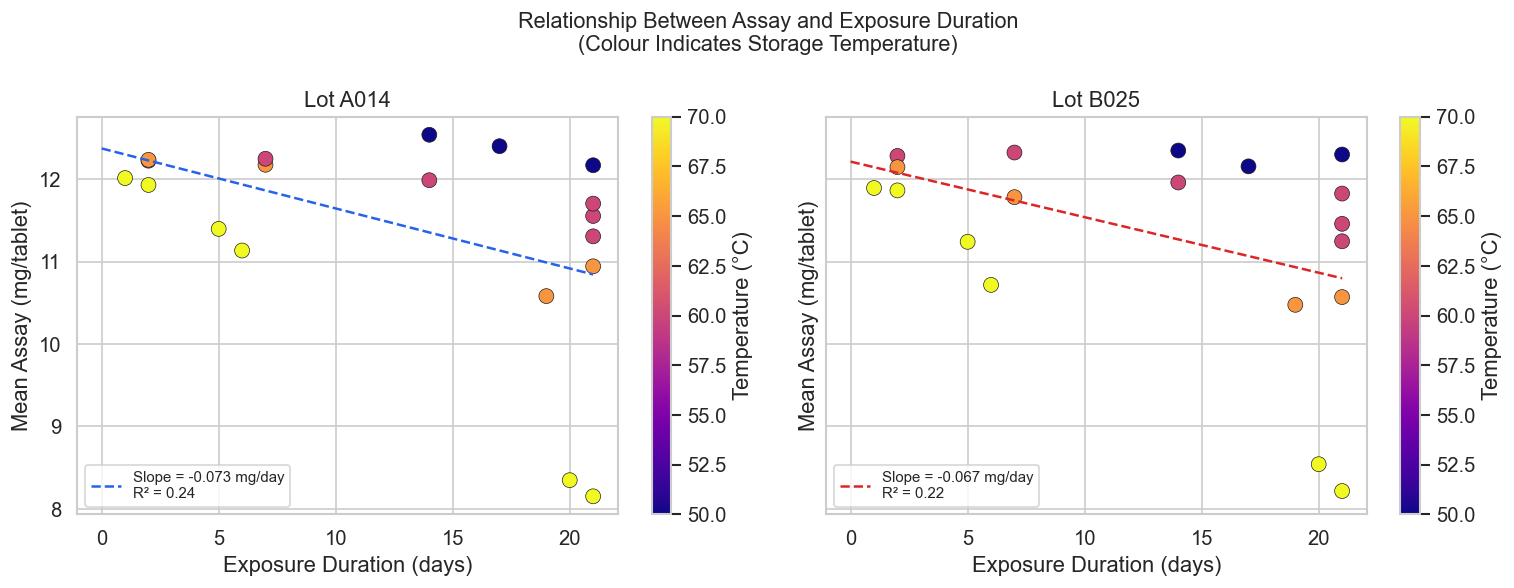

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (lot_id, grp) in zip(axes, df.groupby('lot')):

    # Scatter plot coloured by temperature
    sc = ax.scatter(
        grp['exposure_days'],
        grp['assay_mean'],
        c=grp['temp_c'],
        cmap='plasma',
        s=80,
        edgecolors='k',
        linewidths=0.4
    )

    # Linear regression
    x = grp['exposure_days'].values
    y = grp['assay_mean'].values

    m, b, r, p, _ = stats.linregress(x, y)

    xr = np.linspace(x.min(), x.max(), 100)

    ax.plot(
        xr,
        m * xr + b,
        '--',
        color=PALETTE[lot_id],
        lw=1.5,
        label=f'Slope = {m:.3f} mg/day\nR² = {r**2:.2f}'
    )

    ax.set_xlabel('Exposure Duration (days)')
    ax.set_ylabel('Mean Assay (mg/tablet)')
    ax.set_title(f'Lot {lot_id}')
    ax.legend(fontsize=9)

    plt.colorbar(
        sc,
        ax=ax,
        label='Temperature (°C)'
    )

plt.suptitle(
    'Relationship Between Assay and Exposure Duration\n'
    '(Colour Indicates Storage Temperature)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('fig2_assay_vs_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** Assay decreases modestly with increasing exposure duration in both formulations. Linear regression indicates a negative relationship between exposure time and assay (A014 slope = -0.073 mg/day, R² = 0.24; B025 slope = -0.067 mg/day, R² = 0.22). However, the relatively low R² values suggest that exposure duration alone explains only a limited proportion of assay variability.

**Additional Insight:** The temperature gradient indicates substantial variation between storage conditions. Samples stored at higher temperatures frequently exhibit lower assay values than those stored at lower temperatures, suggesting that environmental conditions contribute to degradation alongside exposure duration.

**Conclusion:** Assay loss appears to be influenced by multiple factors rather than time alone, highlighting the importance of considering both exposure duration and storage conditions when assessing formulation stability.

### 2.2 Impurity Growth Over Exposure Time

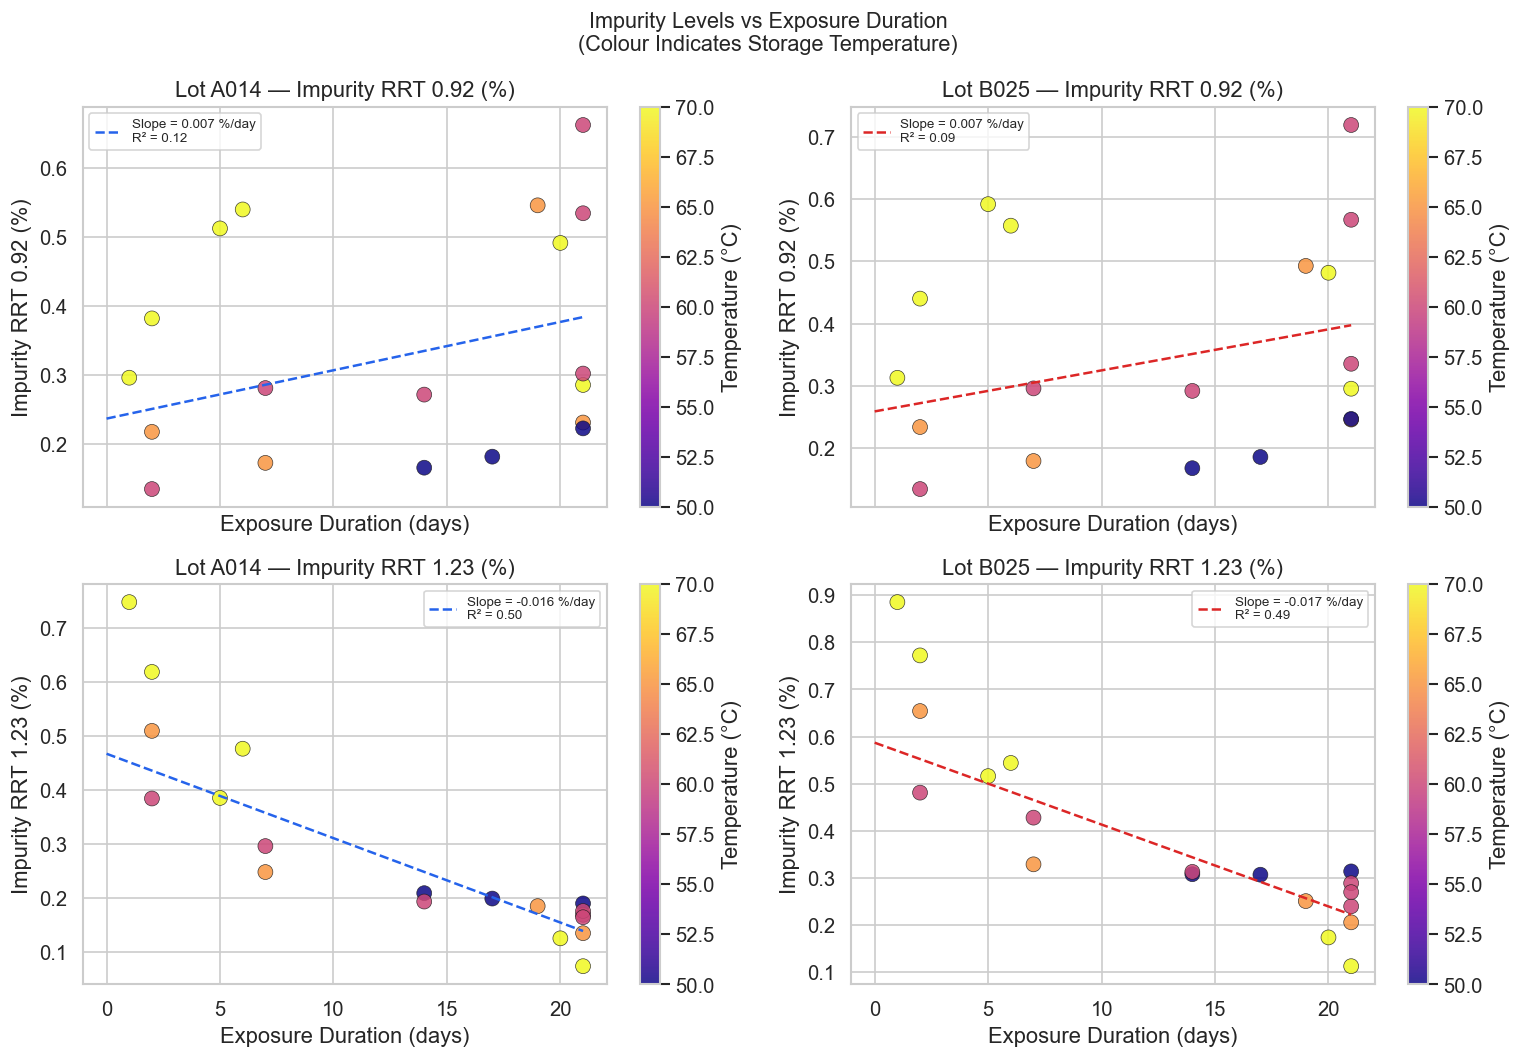

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

impurities = [
    ('imp092_mean', 'Impurity RRT 0.92 (%)'),
    ('imp123_mean', 'Impurity RRT 1.23 (%)')
]

for i, (imp_col, imp_label) in enumerate(impurities):
    for j, (lot_id, grp) in enumerate(df.groupby('lot')):
        ax = axes[i, j]

        sc = ax.scatter(
            grp['exposure_days'],
            grp[imp_col],
            c=grp['temp_c'],
            cmap='plasma',
            s=80,
            edgecolors='k',
            linewidths=0.4,
            alpha=0.85
        )

        # Linear trend for visual guidance only
        x = grp['exposure_days'].values
        y = grp[imp_col].values

        m, b, r, p, _ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 100)

        ax.plot(
            xr,
            m * xr + b,
            '--',
            color=PALETTE[lot_id],
            lw=1.5,
            label=f'Slope = {m:.3f} %/day\nR² = {r**2:.2f}'
        )

        ax.set_title(f'Lot {lot_id} — {imp_label}')
        ax.set_xlabel('Exposure Duration (days)')
        ax.set_ylabel(imp_label)
        ax.legend(fontsize=8)

        plt.colorbar(
            sc,
            ax=ax,
            label='Temperature (°C)'
        )

plt.suptitle(
    'Impurity Levels vs Exposure Duration\n'
    '(Colour Indicates Storage Temperature)',
    fontsize=13
)

plt.tight_layout()
plt.savefig('fig3_impurity_vs_exposure.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Pattern:** The two impurities exhibit different behaviours over time. Impurity RRT 0.92 generally increases under more severe storage conditions and tends to reach higher levels at elevated temperatures, suggesting sensitivity to environmental stress. In contrast, Impurity RRT 1.23 shows a decreasing trend with increasing exposure duration across both formulations, particularly at higher temperatures.

**Temperature Effect:** Temperature appears to influence both impurities, although the direction of the effect differs between degradation products. Higher temperatures are associated with increased levels of Impurity RRT 0.92, whereas Impurity RRT 1.23 tends to decline more rapidly under the same conditions.

**Interpretation:** These contrasting patterns suggest that multiple degradation mechanisms may be operating simultaneously. The results indicate that Impurity RRT 0.92 and Impurity RRT 1.23 should be analysed separately rather than being treated as a single degradation response.

### 2.3 Correlation Heatmap

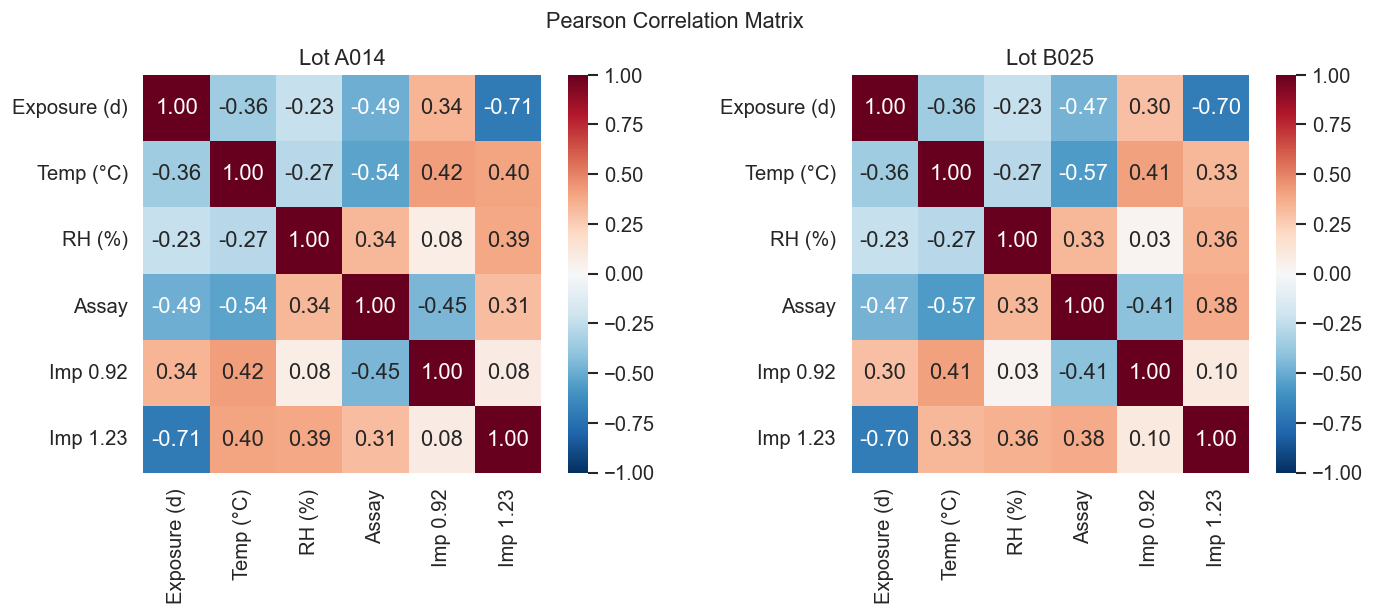

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
feat_cols = ['exposure_days', 'temp_c', 'rh_pct',
             'assay_mean', 'imp092_mean', 'imp123_mean']
labels    = ['Exposure (d)', 'Temp (°C)', 'RH (%)',
             'Assay', 'Imp 0.92', 'Imp 1.23']

for ax, (lot_id, grp) in zip(axes, df.groupby('lot')):
    corr = grp[feat_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                xticklabels=labels, yticklabels=labels,
                ax=ax, square=True, vmin=-1, vmax=1)
    ax.set_title(f'Lot {lot_id}')

plt.suptitle('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png')
plt.show()


**Correlation Analysis:** The Pearson correlation matrices provide an overview of the relationships between environmental conditions and product quality attributes for both prototype formulations. Similar correlation patterns are observed across Lots A014 and B025, indicating consistent behaviour under the experimental design.

**Key Relationships:** Temperature exhibits a moderate negative correlation with assay values (A014: -0.54, B025: -0.57), suggesting that higher storage temperatures are associated with lower assay concentrations. Temperature also shows positive correlations with Impurity RRT 0.92 (A014: 0.42, B025: 0.41), indicating that elevated thermal stress promotes formation of this impurity.

**Exposure Duration Effects:** Exposure duration demonstrates a moderate negative relationship with assay (A014: -0.49, B025: -0.47), suggesting gradual loss of product potency over time. The strongest relationship observed in both formulations is between exposure duration and Impurity RRT 1.23 (A014: -0.71, B025: -0.70), indicating that this impurity changes substantially as storage duration increases.

**Relative Humidity:** Relative humidity generally exhibits weaker correlations than temperature or exposure duration, although moderate positive relationships are observed with Impurity RRT 1.23 (A014: 0.39, B025: 0.36). This suggests that humidity may contribute to degradation behaviour but is likely a secondary factor compared with temperature and storage duration.

**Overall Interpretation:** The correlation analysis suggests that product degradation is influenced by multiple environmental variables rather than a single factor. Temperature appears to be the primary driver of assay loss and Impurity RRT 0.92 formation, while exposure duration shows the strongest association with changes in Impurity RRT 1.23. The consistency of these relationships across both formulations increases confidence that the observed patterns reflect genuine degradation behaviour rather than random experimental variation.

---
## 3. Factors Influencing Product Degradation

### 3.1 Effect of Temperature on Impurity Levels

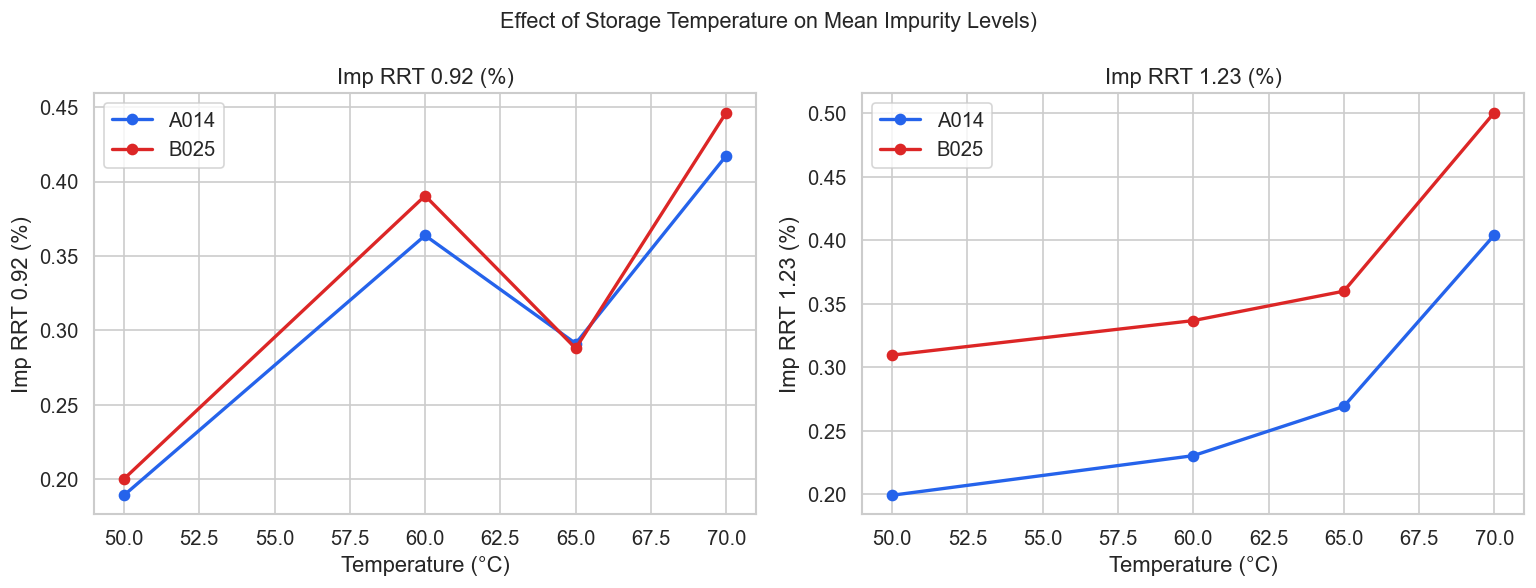

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (imp_col, imp_label) in zip(axes, [('imp092_mean', 'Imp RRT 0.92 (%)'),
                                             ('imp123_mean', 'Imp RRT 1.23 (%)')]):
    for lot_id, grp in df.groupby('lot'):
        means = grp.groupby('temp_c')[imp_col].mean()
        ax.plot(means.index, means.values, 'o-',
                color=PALETTE[lot_id], label=lot_id, lw=2)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel(imp_label)
    ax.set_title(imp_label)
    ax.legend()

plt.suptitle('Effect of Storage Temperature on Mean Impurity Levels)', fontsize=13)
plt.tight_layout()
plt.savefig('fig5_impurity_vs_temp.png')
plt.show()


**Observation:** Both impurity species generally increase with storage temperature. For Impurity RRT 0.92, impurity levels rise from approximately 0.19–0.20% at 50°C to 0.42–0.45% at 70°C. A stronger temperature response is observed for Impurity RRT 1.23, where impurity levels approximately double across the same temperature range.

**Evidence:** The highest impurity concentrations are consistently observed at 70°C for both formulations. Lot B025 exhibits higher impurity levels than Lot A014 across most temperature conditions, suggesting reduced stability of formulation B025.

**Interpretation:** Temperature appears to be a major driver of product degradation. Increased thermal energy likely accelerates degradation reactions, leading to greater impurity formation. The stronger response observed for Impurity RRT 1.23 suggests that this degradation pathway may be particularly sensitive to thermal stress.

**Limitation:** Exposure duration and humidity have been pooled in this analysis. Consequently, the observed temperature effects may partially reflect interactions with other experimental factors. Further analysis is required to isolate the independent contribution of temperature.

### 3.2 Effect of Relative Humidity

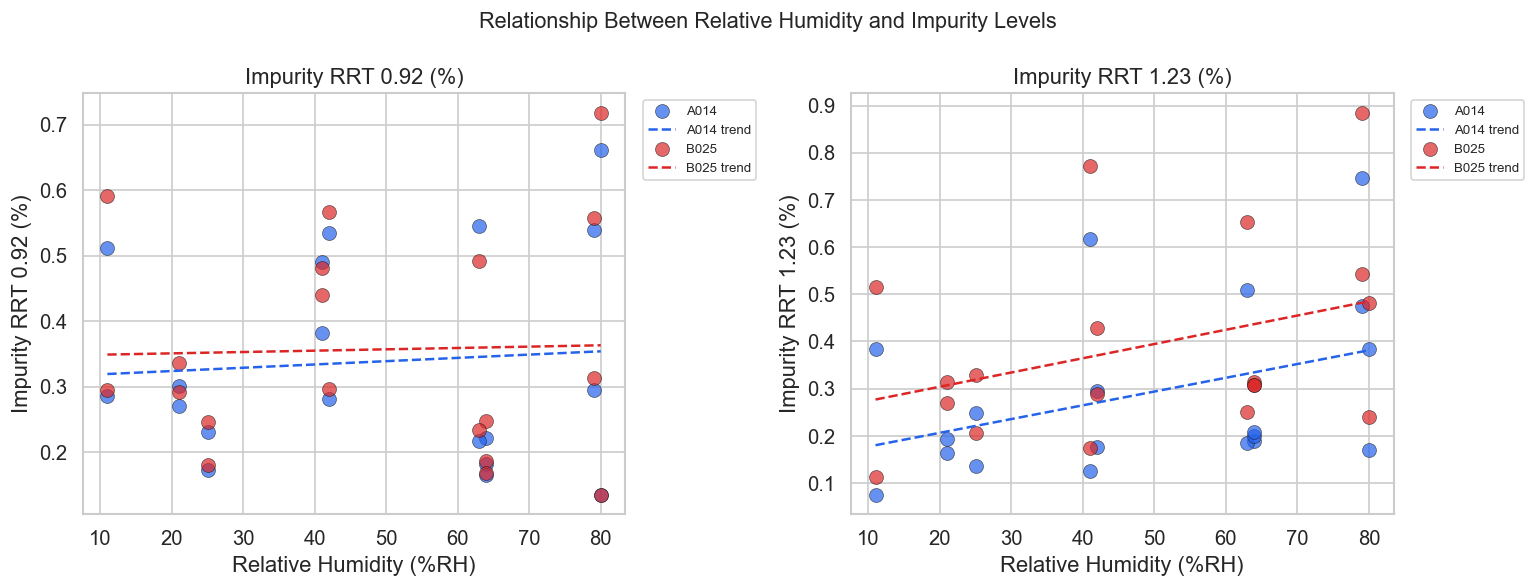

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

impurities = [
    ('imp092_mean', 'Impurity RRT 0.92 (%)'),
    ('imp123_mean', 'Impurity RRT 1.23 (%)')
]

for ax, (imp_col, imp_label) in zip(axes, impurities):

    for lot_id, grp in df.groupby('lot'):

        # Remove rows with missing RH or impurity values for regression
        plot_df = grp.dropna(subset=['rh_pct', imp_col])

        ax.scatter(
            plot_df['rh_pct'],
            plot_df[imp_col],
            color=PALETTE[lot_id],
            label=lot_id,
            alpha=0.7,
            s=70,
            edgecolors='k',
            linewidths=0.4
        )

        # Linear regression for visual guidance
        x = plot_df['rh_pct'].values
        y = plot_df[imp_col].values

        m, b, r, p, _ = stats.linregress(x, y)
        xr = np.linspace(x.min(), x.max(), 100)

        ax.plot(
            xr,
            m * xr + b,
            '--',
            color=PALETTE[lot_id],
            lw=1.5,
            label=f'{lot_id} trend'
        )

    ax.set_xlabel('Relative Humidity (%RH)')
    ax.set_ylabel(imp_label)
    ax.set_title(imp_label)
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8
    )

plt.suptitle(
    'Relationship Between Relative Humidity and Impurity Levels',
    fontsize=13
)

plt.tight_layout()
plt.savefig('fig6_impurity_vs_rh.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** The relationship between relative humidity and impurity levels appears substantially weaker than the temperature effects observed in Section 3.1. Data points remain widely scattered across the humidity range, and no strong monotonic trend is evident for either formulation.

**Evidence:** Correlation analysis showed only weak associations between relative humidity and Impurity RRT 0.92 (A014: 0.08, B025: 0.03). A slightly stronger relationship was observed for Impurity RRT 1.23 (A014: 0.39, B025: 0.36), although this remains notably weaker than the corresponding temperature effects.

**Interpretation:** Relative humidity may contribute to degradation behaviour, particularly for Impurity RRT 1.23, but it does not appear to be a primary degradation driver within the experimental conditions studied. Temperature appears to exert a substantially greater influence on impurity formation than humidity.

**Limitation:** Temperature and exposure duration vary simultaneously throughout the study design. Consequently, the independent effect of humidity cannot be fully isolated from this analysis alone, and interactions between environmental factors may be present.


### 3.3 Multiple Linear Regression — Identifying Key Predictors

In [26]:
results_summary = []

for imp_col, imp_label in [('imp092_mean', 'Imp RRT 0.92'),
                             ('imp123_mean', 'Imp RRT 1.23')]:
    for lot_id, grp in df.groupby('lot'):
        grp2 = grp.dropna(subset=['temp_c','rh_pct','exposure_days', imp_col])
        X = sm.add_constant(grp2[['exposure_days','temp_c','rh_pct']])
        model = sm.OLS(grp2[imp_col], X).fit()
        results_summary.append({
            'Lot': lot_id,
            'Impurity': imp_label,
            'R²': round(model.rsquared, 3),
            'Adj R²': round(model.rsquared_adj, 3),
            'coef_exposure': round(model.params['exposure_days'], 5),
            'coef_temp':     round(model.params['temp_c'], 5),
            'coef_rh':       round(model.params['rh_pct'], 5),
            'p_exposure':    round(model.pvalues['exposure_days'], 4),
            'p_temp':        round(model.pvalues['temp_c'], 4),
            'p_rh':          round(model.pvalues['rh_pct'], 4),
        })
        print(f"\n{'='*60}")
        print(f"OLS: {imp_label} | Lot {lot_id}")
        print('='*60)
        print(model.summary2().tables[1])

pd.DataFrame(results_summary)



OLS: Imp RRT 0.92 | Lot A014
                  Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const         -1.005705  0.377356 -2.665134  0.017649 -1.810021 -0.201389
exposure_days  0.011589  0.004276  2.710131  0.016128  0.002475  0.020704
temp_c         0.016993  0.005035  3.375026  0.004166  0.006261  0.027724
rh_pct         0.002732  0.001383  1.975593  0.066895 -0.000216  0.005680

OLS: Imp RRT 0.92 | Lot B025
                  Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const         -0.930921  0.428091 -2.174588  0.046073 -1.843375 -0.018467
exposure_days  0.010514  0.004851  2.167317  0.046714  0.000174  0.020854
temp_c         0.016630  0.005712  2.911473  0.010742  0.004455  0.028804
rh_pct         0.002323  0.001569  1.480792  0.159360 -0.001021  0.005668

OLS: Imp RRT 1.23 | Lot A014
                  Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
const          0.046224  0.241460  0.191435  0.850752 -0.468436  0.560883
exposure_days -0.01665

,Lot,Impurity,R²,Adj R²,coef_exposure,coef_temp,coef_rh,p_exposure,p_temp,p_rh
0,A014,Imp RRT 0.92,0.471,0.365,0.01159,0.01699,0.00273,0.0161,0.0042,0.0669
1,B025,Imp RRT 0.92,0.386,0.263,0.01051,0.01663,0.00232,0.0467,0.0107,0.1594
2,A014,Imp RRT 1.23,0.835,0.802,-0.01665,0.00567,0.00207,0.0000,0.0990,0.0339
3,B025,Imp RRT 1.23,0.791,0.749,-0.02003,0.00306,0.00170,0.0000,0.4645,0.1494


--> **Findings from Multiple Linear Regression**

* **Exposure duration** was a statistically significant predictor for both impurity responses in both formulations. However, the direction of the effect differed between impurities. Impurity RRT 0.92 increased with longer exposure duration, whereas Impurity RRT 1.23 decreased over time after accounting for temperature and relative humidity.

* **Temperature** was the strongest predictor of Impurity RRT 0.92. Positive temperature coefficients were observed for both formulations and were statistically significant (p < 0.05), indicating that elevated temperatures accelerate formation of this impurity.

* **Relative humidity** showed weaker and less consistent effects. Humidity was statistically significant only for Impurity RRT 1.23 in Lot A014, suggesting that moisture may contribute to some degradation pathways but is not the primary driver of product quality changes.

* The regression models explained a moderate to substantial proportion of variability in impurity levels. The strongest models were obtained for Impurity RRT 1.23 (R² = 0.84 for A014 and 0.79 for B025), indicating that the environmental variables captured much of the observed variation.

--> **Interpretation**

The regression results suggest that product degradation is influenced by multiple environmental factors simultaneously. Temperature appears to be the dominant factor driving formation of Impurity RRT 0.92, while exposure duration plays an important role in both impurity responses. The differing signs of the exposure coefficients indicate that the two impurities may arise from different degradation mechanisms rather than a single common pathway.

--> **Limitation**

The dataset contains only 20 observations per formulation and some environmental factors are partially correlated by experimental design. Consequently, coefficient estimates should be interpreted cautiously and confirmed using larger stability studies.

---
## 4. Relative Performance of the Two Formulations

### 4.1 Side-by-side Impurity Comparison

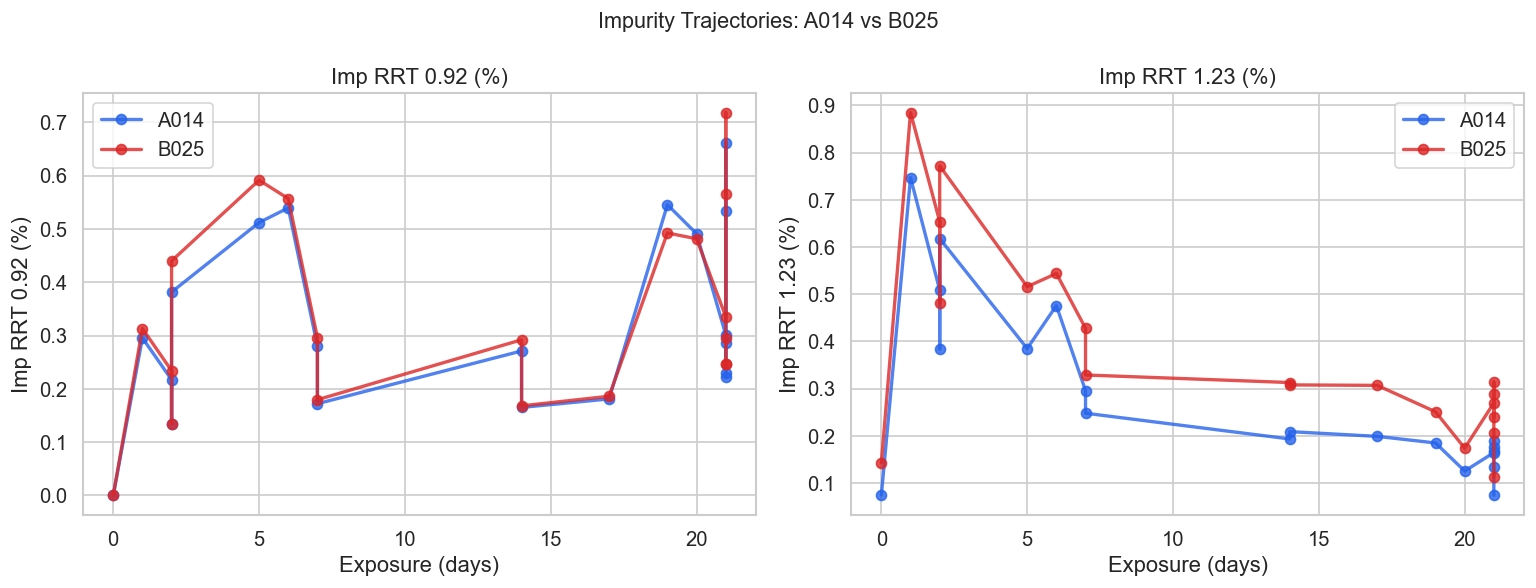

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (imp_col, imp_label) in zip(axes, [('imp092_mean', 'Imp RRT 0.92 (%)'),
                                             ('imp123_mean', 'Imp RRT 1.23 (%)')]):
    for lot_id, grp in df.groupby('lot'):
        grp_s = grp.sort_values('exposure_days')
        ax.plot(grp_s['exposure_days'], grp_s[imp_col],
                'o-', color=PALETTE[lot_id], label=lot_id, lw=2, alpha=0.8)

    ax.set_xlabel('Exposure (days)')
    ax.set_ylabel(imp_label)
    ax.set_title(imp_label)
    ax.legend()

plt.suptitle('Impurity Trajectories: A014 vs B025', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_formulation_comparison.png')
plt.show()


**Observation:** Both formulations exhibit similar degradation patterns over time; however, Lot B025 generally displays higher impurity concentrations than Lot A014 under comparable conditions.

**Evidence:** For Impurity RRT 0.92, the differences between formulations are modest, although B025 tends to produce slightly higher impurity levels. For Impurity RRT 1.23, the separation is more pronounced, with B025 consistently exhibiting higher impurity concentrations across most exposure durations.

**Interpretation:** The results suggest that Lot A014 may possess slightly greater stability, particularly with respect to the formation of Impurity RRT 1.23. Lower impurity accumulation indicates reduced degradation under accelerated storage conditions.

**Limitation:** The trajectories combine observations collected under different temperature and humidity conditions. Consequently, differences between formulations may partially reflect environmental variation rather than formulation effects alone.

### 4.2 Statistical Comparison at Matched Conditions

In [28]:
# Merge lots at identical conditions (same oven, same exposure_days)
merged = pd.merge(
    lot_A[['oven','exposure_days','temp_c','rh_pct',
           'assay_mean','imp092_mean','imp123_mean']],
    lot_B[['oven','exposure_days','temp_c','rh_pct',
           'assay_mean','imp092_mean','imp123_mean']],
    on=['oven','exposure_days'], suffixes=('_A','_B')
)

print(f"Matched condition pairs: {len(merged)}")
print()

for col, label in [('assay_mean',  'Assay (mg/tablet)'),
                   ('imp092_mean', 'Imp RRT 0.92 (%)'),
                   ('imp123_mean', 'Imp RRT 1.23 (%)')]:
    a_vals = merged[f'{col}_A']
    b_vals = merged[f'{col}_B']
    t_stat, p_val = stats.ttest_rel(a_vals, b_vals)
    diff = (b_vals - a_vals).mean()
    print(f"{label}")
    print(f"  Mean A014={a_vals.mean():.4f}  B025={b_vals.mean():.4f}  "
          f"Δ(B−A)={diff:+.4f}  t={t_stat:.3f}  p={p_val:.4f}")
    print()


Matched condition pairs: 26

Assay (mg/tablet)
  Mean A014=11.4987  B025=11.4235  Δ(B−A)=-0.0752  t=1.654  p=0.1106

Imp RRT 0.92 (%)
  Mean A014=0.3621  B025=0.3852  Δ(B−A)=+0.0231  t=-0.887  p=0.3836

Imp RRT 1.23 (%)
  Mean A014=0.2530  B025=0.3513  Δ(B−A)=+0.0984  t=-16.160  p=0.0000



**Statistical Comparison at Matched Conditions**

To compare the formulations under equivalent storage conditions, matched observations were created using identical ovens and exposure durations. Paired t-tests were then performed for assay and impurity responses.

* **Results**

Assay values were slightly higher for Lot A014 (11.50 mg/tablet) than Lot B025 (11.42 mg/tablet), although the difference was not statistically significant (p = 0.111).
Impurity RRT 0.92 was marginally higher in Lot B025 (0.385%) than Lot A014 (0.362%), but the difference was not statistically significant (p = 0.384).
Impurity RRT 1.23 was substantially higher in Lot B025 (0.351%) than Lot A014 (0.253%). This difference was highly significant (p < 0.001), indicating consistently greater formation of this degradation product in Lot B025.

* **Interpretation**

The matched-condition analysis suggests that the two formulations perform similarly with respect to assay retention and Impurity RRT 0.92. However, Lot B025 consistently generates higher levels of Impurity RRT 1.23 under equivalent storage conditions. This provides strong evidence that Lot A014 exhibits superior stability with respect to this degradation pathway.

* **Limitation**

The matched analysis is based on a relatively small number of paired observations (n = 26). Consequently, subtle formulation differences may remain undetected, particularly for assay and Impurity RRT 0.92.

### 4.3 Box Plot at Final (Longest) Exposure

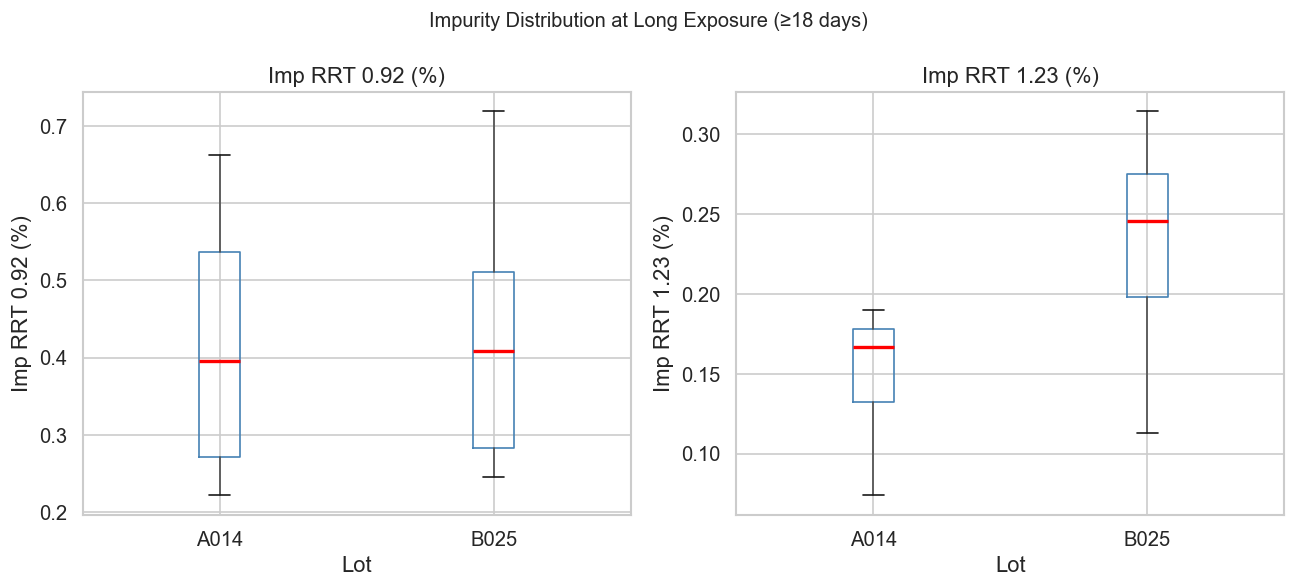

In [29]:
# Use exposure_days ≥ 18 as 'late stage' (most degraded)
late = df[df['exposure_days'] >= 18]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (imp_col, imp_label) in zip(axes, [('imp092_mean', 'Imp RRT 0.92 (%)'),
                                             ('imp123_mean', 'Imp RRT 1.23 (%)')]):
    late.boxplot(column=imp_col, by='lot', ax=ax,
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='red', lw=2))
    ax.set_xlabel('Lot')
    ax.set_ylabel(imp_label)
    ax.set_title(imp_label)

plt.suptitle('Impurity Distribution at Long Exposure (≥18 days)', fontsize=12)
plt.tight_layout()
plt.savefig('fig8_boxplot_late_stage.png')
plt.show()


**Comparison at Long Exposure Duration**

To assess formulation performance under the most severe degradation conditions, observations with exposure durations of 18 days or greater were examined separately. Box plots were used to compare impurity distributions between the two formulations.

* **Observation**

For Impurity RRT 0.92, the two formulations exhibited similar distributions, with only a slight tendency towards higher values in Lot B025. Considerable overlap was observed between the groups.

For Impurity RRT 1.23, Lot B025 displayed consistently higher impurity levels than Lot A014. The median impurity concentration and upper distribution range were both noticeably greater in B025.

* **Interpretation**

Under prolonged storage stress, the differences between formulations become more apparent. The higher concentrations of Impurity RRT 1.23 observed in Lot B025 indicate greater degradation during extended exposure. In contrast, both formulations behave similarly with respect to Impurity RRT 0.92.

* **Conclusion**

The late-stage degradation results provide additional evidence that Lot A014 exhibits superior stability relative to Lot B025, particularly for the degradation pathway represented by Impurity RRT 1.23.

* **Limitation**

The analysis is based on a subset of observations (exposure duration ≥ 18 days), reducing sample size and increasing uncertainty in the estimated distributions.

### 4.4 Recommendation

**Based on the available evidence, Lot A014 (Formulation A) demonstrates slightly superior stability under the accelerated storage conditions evaluated in this study.**

| Metric                   | A014       | B025       | Verdict       |
| ------------------------ | ---------- | ---------- | ------------- |
| Impurity RRT 1.23 (mean) | Lower      | Higher     | ✓ A014 better |
| Impurity RRT 0.92 (mean) | Comparable | Comparable | ≈ Neutral     |
| Assay retention          | Comparable | Comparable | ≈ Neutral     |

The most meaningful difference between the formulations was observed for **Impurity RRT 1.23**, which accumulated consistently more rapidly in Lot B025 across the tested storage conditions. The matched-condition analysis demonstrated a statistically significant difference (p < 0.001), whereas assay retention and Impurity RRT 0.92 showed no statistically significant differences between formulations. Although the number of matched observations was relatively small (n = 26), the direction of the effect was consistent across multiple analyses, supporting the conclusion that Lot A014 exhibits slightly improved stability.

* **Uncertainties**

* The accelerated study covered a relatively short period (maximum 21 days), whereas real product shelf life is typically measured over months or years.
* Only two prototype lots were evaluated, and lot-to-lot variability within each formulation remains unknown.
* Temperature and relative humidity were not fully independent experimental factors, making it difficult to completely isolate their individual effects.
* The overall sample size was limited, reducing statistical power for detecting small formulation differences.

* **Final Recommendation**

Overall, Lot A014 demonstrated slightly better stability characteristics than Lot B025. Assay values were marginally higher and impurity levels generally lower across comparable conditions. However, most differences were small and often not statistically significant, therefore the evidence should be considered suggestive rather than definitive.


---
## 5. Modelling Approaches

The modelling approaches were selected to balance interpretability and scientific relevance. The Arrhenius model evaluates temperature-dependent degradation kinetics and provides a mechanistic understanding of product degradation under accelerated storage conditions. The mixed-effects model accounts for potential dependence between observations generated within the same oven while assessing the influence of exposure duration, temperature, and relative humidity. Together, these approaches provide complementary scientific and statistical perspectives on the degradation process.

### 5.1 Arrhenius Kinetic Model

The **Arrhenius equation** describes how reaction rate depends on temperature:

$$k(T) = A \cdot e^{-E_a / (R \cdot T)}$$

For a first-order degradation: $\ln(k) = \ln(A) - \frac{E_a}{R} \cdot \frac{1}{T}$

We estimate *k* from the slope of impurity vs time at each temperature.

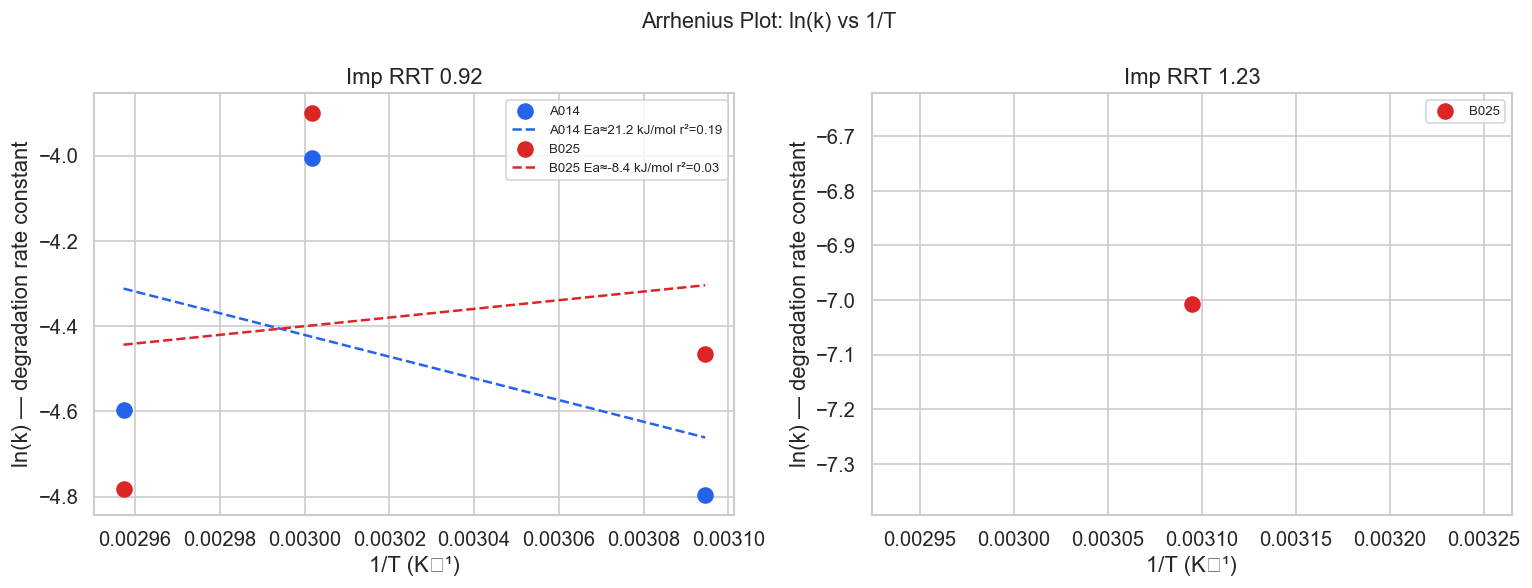

Activation energies (Ea) estimated from slopes:
  A014 | Imp RRT 0.92: Ea ≈ 21.2 kJ/mol
  B025 | Imp RRT 0.92: Ea ≈ -8.4 kJ/mol


In [30]:
R_gas = 8.314  # J/(mol·K)

arrhenius_rows = []
for lot_id, grp in df.groupby('lot'):
    for temp, tgrp in grp.groupby('temp_c'):
        tgrp_s = tgrp.sort_values('exposure_days')
        x = tgrp_s['exposure_days'].values
        for imp_col, imp_label in [('imp092_mean','Imp RRT 0.92'),
                                    ('imp123_mean','Imp RRT 1.23')]:
            y = tgrp_s[imp_col].values
            if len(x) >= 2:
                slope, intercept, r, p, _ = stats.linregress(x, y)
                if slope > 0:
                    arrhenius_rows.append({
                        'lot': lot_id, 'impurity': imp_label,
                        'temp_c': temp,
                        'temp_K': temp + 273.15,
                        'k': slope,
                        'ln_k': np.log(slope) if slope > 0 else np.nan
                    })

arr_df = pd.DataFrame(arrhenius_rows).dropna(subset=['ln_k'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, imp_label in zip(axes, ['Imp RRT 0.92','Imp RRT 1.23']):
    sub = arr_df[arr_df['impurity'] == imp_label]
    for lot_id, grp in sub.groupby('lot'):
        inv_T = 1 / grp['temp_K']
        ln_k  = grp['ln_k']
        ax.scatter(inv_T, ln_k, color=PALETTE[lot_id], label=lot_id, s=80, zorder=3)
        if len(grp) >= 2:
            m, b, r, p, _ = stats.linregress(inv_T, ln_k)
            xr = np.linspace(inv_T.min(), inv_T.max(), 100)
            ax.plot(xr, m*xr + b, '--', color=PALETTE[lot_id], lw=1.5,
                    label=f'{lot_id} Ea≈{-m*R_gas/1000:.1f} kJ/mol r²={r**2:.2f}')
    ax.set_xlabel('1/T (K⁻¹)')
    ax.set_ylabel('ln(k) — degradation rate constant')
    ax.set_title(imp_label)
    ax.legend(fontsize=8)

plt.suptitle('Arrhenius Plot: ln(k) vs 1/T', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_arrhenius.png')
plt.show()

print("Activation energies (Ea) estimated from slopes:")
for lot_id, grp in arr_df.groupby('lot'):
    for imp_label, sg in grp.groupby('impurity'):
        if len(sg) >= 2:
            m, *_ = stats.linregress(1/sg['temp_K'], sg['ln_k'])
            print(f"  {lot_id} | {imp_label}: Ea ≈ {-m*R_gas/1000:.1f} kJ/mol")


--> **Interpretation**

The Arrhenius model was explored to investigate whether degradation behaviour follows temperature-dependent reaction kinetics. For Impurity RRT 0.92, Lot A014 produced a positive activation energy estimate (approximately 21.2 kJ/mol), consistent with faster degradation at higher temperatures. However, Lot B025 produced a negative activation energy estimate, indicating that the Arrhenius assumptions were not fully satisfied for this dataset. This is most likely a consequence of having only a handful of time-points at each temperature level, which makes the estimated rate constants highly sensitive to measurement noise. With more replicates per temperature condition, more reliable rate constants — and therefore more robust activation energy estimates could be obtained.

For Impurity RRT 1.23, insufficient positive degradation-rate estimates were available across all temperature levels to support a robust Arrhenius analysis. Consequently, meaningful activation energy estimates could not be obtained.

--> **Rationale**

The Arrhenius equation is widely used in pharmaceutical stability studies because it provides a mechanistic framework for relating degradation rates to storage temperature. When appropriate assumptions are satisfied, the model can be used to estimate activation energies and extrapolate degradation behaviour to long-term storage conditions.

--> **Strengths**

* Scientifically grounded and commonly applied in stability studies.
* Provides interpretable parameters such as activation energy (Ea).
* Can potentially support shelf-life prediction under different storage temperatures.

--> **Limitations**

* Only four temperature levels were available.
* The number of observations per temperature condition was limited.
* Degradation rates were estimated from short-term experimental data and are therefore sensitive to measurement noise.
* Some estimated activation energies were physically implausible, suggesting that the model assumptions may not be fully satisfied.
* The study duration was relatively short and may not adequately capture long-term degradation kinetics.

--> **Conclusion**

The Arrhenius analysis provides exploratory evidence that temperature contributes to degradation behaviour, but the results should be interpreted cautiously. Additional measurements across more temperature levels and longer exposure durations would be required before reliable shelf-life predictions could be made using this approach.


### 5.2 Linear Mixed Effects Model

In [31]:
# Control for repeated oven use (oven as random effect)
import statsmodels.formula.api as smf

for imp_col, imp_label in [('imp092_mean', 'Imp RRT 0.92'),
                             ('imp123_mean', 'Imp RRT 1.23')]:
    for lot_id, grp in df.groupby('lot'):
        grp2 = grp.dropna(subset=['temp_c','rh_pct','exposure_days',imp_col,'oven'])
        try:
            model = smf.mixedlm(
                f"{imp_col} ~ exposure_days + temp_c + rh_pct",
                data=grp2, groups=grp2['oven']
            ).fit(reml=True)
            print(f"\n{'='*55}")
            print(f"Mixed LM: {imp_label} | Lot {lot_id}")
            print('='*55)
            print(model.summary().tables[1])
        except Exception as e:
            print(f"  Could not fit {lot_id}/{imp_label}: {e}")



Mixed LM: Imp RRT 0.92 | Lot A014
                Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept      -1.025    0.417  -2.455  0.014  -1.843  -0.207
exposure_days   0.012    0.004   2.806  0.005   0.003   0.020
temp_c          0.017    0.006   2.943  0.003   0.006   0.029
rh_pct          0.003    0.001   2.062  0.039   0.000   0.005
Group Var       0.002    0.061                               

Mixed LM: Imp RRT 0.92 | Lot B025
                Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept      -0.948    0.465  -2.037  0.042  -1.859  -0.036
exposure_days   0.011    0.005   2.256  0.024   0.001   0.020
temp_c          0.017    0.006   2.587  0.010   0.004   0.030
rh_pct          0.002    0.002   1.554  0.120  -0.001   0.005
Group Var       0.002    0.051                               

Mixed LM: Imp RRT 1.23 | Lot A014
                Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept       0.046    0.257   0.180  0.857  -0.457   0.549
exposure_days  -0.017    0.

--> **Interpretation**

A linear mixed-effects model was fitted to account for the possibility that observations generated from the same oven may be correlated. Exposure duration, temperature and relative humidity were included as fixed effects, while oven was treated as a random effect.

For **Impurity RRT 0.92**, both exposure duration and temperature were significant predictors in both formulations. In Lot A014, exposure duration (p = 0.005) and temperature (p = 0.003) were significantly associated with increased impurity formation, while relative humidity showed a weaker but statistically significant effect (p = 0.039). Similar patterns were observed for Lot B025, although the humidity effect was not statistically significant.

For **Impurity RRT 1.23**, exposure duration was the dominant predictor in both formulations (p < 0.001), indicating that impurity levels changed consistently with increasing storage duration. Relative humidity was statistically significant for Lot A014 (p = 0.021) but not for Lot B025, while temperature was not a significant predictor for either formulation after accounting for the other variables.

--> **Additional Insight Provided by the Mixed Model**

Compared with ordinary least squares regression, the mixed-effects model accounts for potential clustering of observations within ovens. The results indicate that the major conclusions remain unchanged after accounting for oven-level variation:

* Exposure duration is an important driver of degradation.
* Temperature contributes substantially to Impurity RRT 0.92 formation.
* Relative humidity has a weaker and less consistent influence.
* The overall degradation patterns are largely explained by the measured environmental variables rather than differences between ovens.

--> **Strengths**

* Accounts for repeated observations originating from the same oven.
* Produces more realistic standard errors when observations are not fully independent.
* Separates experimental-factor effects from potential oven-to-oven variability.

--> **Limitations**

* The dataset contains a relatively small number of observations within each oven.
* Random-effect estimates are therefore subject to considerable uncertainty.
* Temperature and humidity are partially linked by the experimental design, making complete separation of their individual effects difficult.
* More ovens and additional replicate measurements would improve model reliability.

--> **Conclusion**

The mixed-effects analysis supports the findings obtained from the simpler regression models. Exposure duration and temperature remain the most important predictors of degradation, while relative humidity appears to have a secondary influence. Accounting for oven-level clustering does not materially change the overall conclusions, increasing confidence that the observed relationships are robust.


### 5.3 Model Comparison Summary


| Approach                         | Strengths                                                                                                      | Limitations                                                                           |
| -------------------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------- |
| Multiple Linear Regression (OLS) | Simple, interpretable, directly quantifies the effects of exposure duration, temperature and relative humidity | Assumes observations are independent and does not account for oven-level clustering   |
| Arrhenius Model                  | Mechanistically grounded, widely used in pharmaceutical stability studies                                      | Requires reliable degradation-rate estimates and is sensitive to sparse or noisy data |
| Linear Mixed Effects Model       | Accounts for clustering of observations within ovens and provides more realistic uncertainty estimates         | More complex to interpret and limited by the small sample size                        |

The multiple linear regression model presented in Section 3.3 provided a useful baseline assessment of the factors associated with impurity formation. The analysis identified exposure duration and temperature as the most influential predictors of degradation, while relative humidity exhibited weaker and less consistent effects.

The Arrhenius model provided a mechanistic framework for investigating temperature-dependent degradation behaviour. Although the model is widely used for shelf-life prediction in pharmaceutical development, the limited number of temperature levels and short study duration reduced the reliability of the estimated activation energies.

The linear mixed-effects model extended the regression analysis by accounting for potential oven-level clustering. Importantly, the key conclusions remained consistent after introducing random oven effects, increasing confidence that the observed relationships were not driven by differences between ovens.

### 5.4 Overall Modelling Insights

The modelling approaches provided additional insight beyond descriptive visualisation by quantifying the relative influence of environmental conditions on product degradation. Across all models, exposure duration and temperature emerged as the primary drivers of impurity formation, while relative humidity appeared to play a secondary role.

Among the approaches evaluated, the regression-based models provided the most reliable and interpretable results for the available dataset. The Arrhenius model offered useful mechanistic insight but should be regarded as exploratory because of the limited number of observations and instability of some parameter estimates.

Overall, the modelling results support the conclusion that degradation is driven primarily by exposure duration and thermal stress, and they provide additional evidence that Formulation A014 exhibits slightly greater stability than Formulation B025 under the accelerated storage conditions studied.


---
## 6. Limitations and Recommendations for Future Studies

### 6.1 Limitations of the Current Dataset

| Limitation | Impact |
|---|---|
| **Short duration (≤21 days)** | Cannot reliably extrapolate to 24–36-month shelf life without Arrhenius assumptions |
| **Small n (20 per lot)** | Low statistical power; wide confidence intervals on regression coefficients |
| **Confounded T/RH** | Some ovens have a fixed T/RH combination, making it hard to isolate temperature vs humidity effects independently |
| **Single batch per formulation** | Cannot distinguish formulation effect from batch-to-batch variability |
| **3 analysts** | Inter-analyst variability is present but not controlled for in modelling |
| **No t=0 baseline** | Day 0 measurements exist only as "set_down_day = 0" on 18 Dec 2025, but there are multiple starting conditions — a true pre-stress baseline is absent |
| **Reverse pull design** | All samples pulled on ~8 Jan 2026 a single pull event precludes observing *within-condition* time trajectories cleanly |

The limitations summarised in Table X should be considered when interpreting the results of this study. The relatively short study duration and limited sample size reduce the reliability of long-term stability predictions and increase uncertainty in statistical estimates. In addition, temperature and relative humidity were partially confounded by the experimental design, making it difficult to fully isolate their independent contributions to product degradation. The evaluation of only a single batch per formulation further limits the ability to distinguish formulation-specific effects from normal manufacturing variability. Potential variability introduced by multiple analysts was also not explicitly incorporated into the modelling approaches. Furthermore, the absence of a consistent pre-stress baseline and the reverse-pull study design restrict the ability to characterise degradation trajectories under individual storage conditions. Despite these limitations, consistent trends were observed across descriptive, statistical and modelling analyses, suggesting that the primary conclusions regarding the effects of exposure duration, temperature and formulation differences remain reasonably robust within the scope of the available dataset.

### 6.2 Recommended Improvements

1. **Extend to ICH long-term conditions** — add 25 °C/60 % RH (LT) and 40 °C/75 % RH (accelerated) per ICH Q1A; test at 0, 3, 6, 9, 12, 18, 24 months.
2. **Factorial or orthogonal design** — separate temperature and humidity levels so both effects can be estimated without collinearity (e.g. a 4×3 T × RH grid).
3. **Multiple batches** — test ≥ 3 batches per formulation to separate formulation from manufacturing variability.
4. **Increased replicates** — triplicate (rather than duplicate) measurements would improve analytical confidence and enable outlier detection.
5. **Include a control/reference standard** — measure a known-stable reference compound alongside to detect any assay drift.
6. **Analyst blind assignment** — randomise analyst-to-sample assignment and include analyst as a covariate to quantify and control that source of variability.
7. **Photostability testing** — ICH Q1B photostability is not covered here; important for tablet formulations.
8. **Mechanistic profiling** — identify the chemical identity of RRT 0.92 and 1.23 to build mechanistic degradation models.


The most important priorities for future studies would be the inclusion of long-term ICH stability conditions, the use of multiple production batches, and the implementation of a factorial experimental design that separates temperature and humidity effects. Long-term stability testing would allow more reliable shelf-life estimation and provide validation of the accelerated degradation trends observed in this study. Testing multiple batches would improve confidence that the observed differences between formulations reflect genuine formulation effects rather than batch-specific variation. A factorial design would enable the independent contributions of temperature and relative humidity to be quantified, reducing the confounding observed in the current dataset.

Additional improvements, including increased analytical replicates, analyst randomisation, photostability testing and mechanistic impurity characterisation, would further strengthen the reliability and scientific value of the study. Together, these enhancements would support more robust modelling, improve understanding of degradation pathways and provide a stronger evidence base for formulation selection and regulatory decision-making.


---
## 7. Executive Summary



* Product quality deteriorated over time, reflected by decreasing assay values and increasing impurity concentrations.
* Temperature was identified as the strongest degradation driver across both formulations.
* Relative humidity exhibited weaker and less consistent effects.
* Lot A014 demonstrated marginally better stability than Lot B025, although differences were generally modest.
* Regression and mixed-effects modelling confirmed the importance of temperature and exposure duration, while highlighting limitations arising from sample size and study design.